In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow import keras
import os
from sklearn.linear_model import RANSACRegressor
import math

# --- 1. CONFIGURACIÓN DEL PIPELINE ROBUSTO ---
# ----------------------------------------------------
# -- Parámetros del "Cazador de Renglones" (RANSAC Iterativo) --

# Ángulo máximo de inclinación (en grados) que se permite para un renglón.
MAX_LINE_ANGLE = 35.0

# Distancia máxima (en píxeles) para que un caracter sea considerado parte de la línea principal.
DISTANCE_THRESHOLD = 5.0 

# Un renglón se considera válido solo si tiene este número de caracteres o más.
MIN_CHARS_PER_LINE = 4

# -- Configuración de Detección de Separadores (se mantiene) --
ENABLE_SEPARATOR_DETECTION = True
SEPARATOR_CHAR = " "
GAP_THRESHOLD_MULTIPLIER = 1.8 
MIN_CHARS_FOR_SEPARATOR_DETECTION = 3
# ----------------------------------------------------


# --- 2. FUNCIONES DE AYUDA DEL NUEVO PIPELINE ---
# ----------------------------------------------------

def _get_box_details(boxes_raw):
    """Convierte las cajas de YOLO a una estructura de datos más rica."""
    boxes_data = []
    for b in boxes_raw:
        area = (b[2] - b[0]) * (b[3] - b[1])
        if area <= 0: continue
        center_x = b[0] + (b[2] - b[0]) / 2
        center_y = b[1] + (b[3] - b[1]) / 2
        boxes_data.append({'box': b, 'area': area, 'center': (center_x, center_y)})
    return boxes_data

def _find_text_lines_ransac(box_details):
    """
    Versión optimizada que primero intenta un ajuste lineal simple.
    Si falla, recurre al RANSAC iterativo.
    """
    if len(box_details) < MIN_CHARS_PER_LINE:
        return []

    # --- INICIO DE LA OPTIMIZACIÓN: VERIFICACIÓN RÁPIDA ---
    
    # 1. Extraer todos los puntos
    centers_x = np.array([b['center'][0] for b in box_details]).reshape(-1, 1)
    centers_y = np.array([b['center'][1] for b in box_details])
    
    # 2. Intentar un ajuste lineal simple (muy rápido)
    try:
        slope, intercept = np.polyfit(centers_x.flatten(), centers_y, 1)
        
        # 3. Calcular el error de cada punto a esta línea
        distances = np.abs(centers_y - (slope * centers_x.flatten() + intercept)) / np.sqrt(slope**2 + 1)
        max_error = np.max(distances)
        
        # 4. Comprobar el ángulo de la línea
        angle_deg = np.degrees(np.arctan(slope))
        
        # 5. DECISIÓN: Si el error máximo es pequeño y el ángulo es aceptable, es una sola línea limpia
        if max_error < DISTANCE_THRESHOLD and abs(angle_deg) <= MAX_LINE_ANGLE:
            print("  Vía Rápida: Todos los puntos forman una sola línea válida.")
            # Devolvemos todos los caracteres como un único renglón
            return [box_details]
            
    except np.linalg.LinAlgError:
        # polyfit puede fallar si todos los puntos están en una línea vertical perfecta
        pass # Simplemente continuamos al método robusto

    # --- FIN DE LA OPTIMIZACIÓN ---
    
    
    # --- MÉTODO ROBUSTO (RANSAC ITERATIVO) ---
    # Si la verificación rápida falló, ejecutamos el proceso completo
    print("  Vía Rápida falló. Usando RANSAC iterativo para encontrar renglones...")
    
    remaining_boxes = list(box_details)
    found_lines = []

    while len(remaining_boxes) >= MIN_CHARS_PER_LINE:
        centers_x = np.array([b['center'][0] for b in remaining_boxes]).reshape(-1, 1)
        centers_y = np.array([b['center'][1] for b in remaining_boxes])

        try:
            ransac = RANSACRegressor(random_state=42)
            ransac.fit(centers_x, centers_y)
            
            slope = ransac.estimator_.coef_[0]
            angle_deg = np.degrees(np.arctan(slope))
            
            if abs(angle_deg) > MAX_LINE_ANGLE:
                break
            
            distances = np.abs(centers_y - ransac.predict(centers_x)) / np.sqrt(slope**2 + 1)
            
            current_line, outliers = [], []
            for i, box in enumerate(remaining_boxes):
                if distances[i] < DISTANCE_THRESHOLD:
                    current_line.append(box)
                else:
                    outliers.append(box)
            
            if len(current_line) >= MIN_CHARS_PER_LINE:
                found_lines.append(current_line)
            
            # Si no se eliminan suficientes outliers, detenemos para evitar bucles infinitos
            if len(outliers) >= len(remaining_boxes) - 1:
                break
                
            remaining_boxes = outliers
        except ValueError:
            break
            
    return found_lines

def _select_main_line_by_size(lines):
    """
    Si hay múltiples renglones, selecciona el que tenga el área promedio de caracteres más grande.
    """
    if not lines: return []
    if len(lines) == 1: return lines[0]

    print(f"  Múltiples renglones detectados. Analizando tamaño promedio...")
    
    best_line = None
    max_avg_area = -1

    for i, line in enumerate(lines):
        avg_area = np.mean([b['area'] for b in line])
        print(f"    - Renglón {i+1} ({len(line)} chars) tiene un área promedio de {avg_area:.2f}")
        if avg_area > max_avg_area:
            max_avg_area = avg_area
            best_line = line
            
    print(f"  --> Renglón principal seleccionado con área promedio de {max_avg_area:.2f}")
    return best_line

def _classify_and_assemble(line, original_image, keras_model, class_names, preprocess_fn):
    """Clasifica cada caracter de la línea final e inserta separadores."""
    if not line: return "", []
        
    predicted_chars = []
    for box_data in line:
        x1, y1, x2, y2 = map(int, box_data['box'])
        crop = original_image[y1:y2, x1:x2]
        keras_input = preprocess_fn(crop)
        prediction = keras_model.predict(keras_input, verbose=0)
        class_index = np.argmax(prediction[0])
        predicted_char = class_names[class_index] if class_index < len(class_names) else "?"
        predicted_chars.append(predicted_char)

    if not ENABLE_SEPARATOR_DETECTION or len(line) < MIN_CHARS_FOR_SEPARATOR_DETECTION:
        return "".join(predicted_chars), [b['box'] for b in line]
    
    gaps = [line[i+1]['center'][0] - line[i]['center'][0] for i in range(len(line)-1)]
    if not gaps: return "".join(predicted_chars), [b['box'] for b in line]

    median_gap = np.median(gaps)
    gap_cutoff = median_gap * GAP_THRESHOLD_MULTIPLIER

    final_plate_string = predicted_chars[0]
    for i in range(len(gaps)):
        if gaps[i] > gap_cutoff:
            final_plate_string += SEPARATOR_CHAR
        final_plate_string += predicted_chars[i+1]

    return final_plate_string, [b['box'] for b in line]

print("✅ Funciones del pipeline de inferencia robusto (RANSAC) definidas.")

✅ Funciones del pipeline de inferencia robusto (RANSAC) definidas.


In [30]:
def run_robust_inference_pipeline(image_path, yolo_model, keras_model, keras_class_names, preprocess_for_keras_fn):
    """
    Orquesta el pipeline robusto: Detectar -> Cazar Renglones -> Seleccionar -> Clasificar.
    Devuelve el texto, las cajas finales y las cajas iniciales.
    """
    img_original = cv2.imread(image_path)
    if img_original is None:
        return None, None, None

    # 1. Detección YOLO
    yolo_results = yolo_model(img_original, verbose=False)
    boxes_raw = yolo_results[0].boxes.xyxy.cpu().numpy()
    initial_boxes_to_draw = list(boxes_raw) # Guardar para depuración
    
    if len(boxes_raw) == 0:
        print("YOLO no detectó ningún caracter.")
        return "", initial_boxes_to_draw, []

    print(f"YOLO detectó {len(boxes_raw)} cajas candidatas.")
    
    box_details = _get_box_details(boxes_raw)

    # 2. Encontrar todos los renglones de texto válidos
    found_lines = _find_text_lines_ransac(box_details)
    
    if not found_lines:
        print("No se encontraron renglones de texto válidos que cumplan los criterios.")
        return "", initial_boxes_to_draw, []

    # 3. Seleccionar el renglón principal por tamaño
    main_line = _select_main_line_by_size(found_lines)
    
    # 4. Ordenar la línea principal por X antes de clasificar
    main_line.sort(key=lambda b: b['center'][0])

    # 5. Clasificar y Ensamblar
    final_plate_string, final_boxes_to_draw = _classify_and_assemble(
        main_line, img_original, keras_model, keras_class_names, preprocess_for_keras_fn
    )
    
    return final_plate_string, final_boxes_to_draw, initial_boxes_to_draw

print("✅ Función principal 'run_robust_inference_pipeline' definida.")

✅ Función principal 'run_robust_inference_pipeline' definida.


YOLO detectó 9 cajas candidatas.
  Vía Rápida: Todos los puntos forman una sola línea válida.

--- RESULTADO FINAL ---
Placa Detectada: RDW-435-B


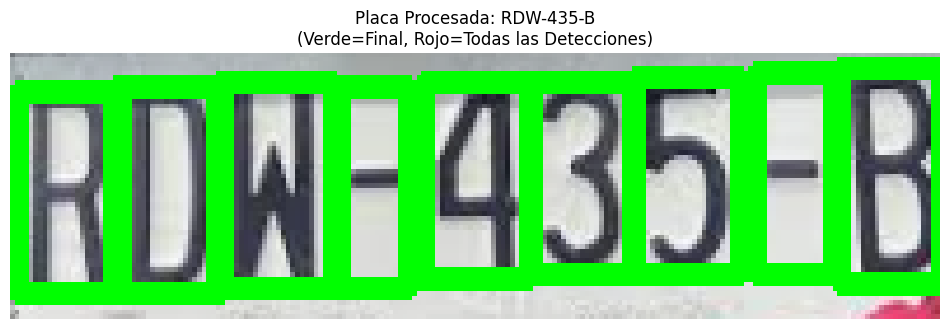

In [62]:
# --- CONFIGURACIÓN DEL EJEMPLO ---
# (Asegúrate de que estas rutas y variables existan)
YOLO_MODEL_PATH = "checkpoints/Yolo_Char2.pt"
KERAS_MODEL_PATH = "checkpoints/CNN_char_classifier.keras"

KERAS_INPUT_SIZE = (48, 48)
KERAS_CLASS_NAMES = ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


# --- CARGAR DEPENDENCIAS ---
def preprocess_for_keras(crop_img):
    img_resized = cv2.resize(crop_img, KERAS_INPUT_SIZE)
    if len(img_resized.shape) == 3: img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    else: img_gray = img_resized
    img_float = img_gray.astype('float32')
    return np.expand_dims(np.expand_dims(img_float, axis=-1), axis=0)

yolo_model = YOLO(YOLO_MODEL_PATH)
keras_model = keras.models.load_model(KERAS_MODEL_PATH)
# ------------------------------

IMAGE_PATH = "datasets/eval_final/RDW-435-B.jpg" # ⚠️ ¡Ajusta esta ruta!

# --- EJECUTAR PIPELINE ---
plate_text, final_boxes, initial_boxes = run_robust_inference_pipeline(
    IMAGE_PATH,
    yolo_model,
    keras_model,
    KERAS_CLASS_NAMES,
    preprocess_for_keras
)

# --- MOSTRAR RESULTADO ---
if plate_text is not None:
    print("\n" + "="*30)
    print("--- RESULTADO FINAL ---")
    print(f"Placa Detectada: {plate_text}")
    print("="*30)
    
    # --- VISUALIZACIÓN DE DEPURACIÓN ---
    img_visualizada = cv2.imread(IMAGE_PATH)
    
    # 1. Dibujar TODAS las cajas detectadas por YOLO en ROJO
    for box in initial_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_visualizada, (x1, y1), (x2, y2), (255, 0, 0), 2) # Rojo
        
    # 2. Dibujar las cajas FINALES (las que pasaron los filtros) en VERDE
    for box in final_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img_visualizada, (x1, y1), (x2, y2), (0, 255, 0), 3) # Verde y más grueso
    
    img_rgb = cv2.cvtColor(img_visualizada, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(img_rgb)
    plt.title(f"Placa Procesada: {plate_text}\n(Verde=Final, Rojo=Todas las Detecciones)")
    plt.axis('off')
    plt.show()